In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

In [2]:
Spotify_limpio = pd.read_csv('Spotify_data_total.csv')

print(f"Total de registros cargados: {len(Spotify_limpio)}")
Spotify_limpio.head()

Total de registros cargados: 520


,EDAD,GENERO,ANTIGUEDAD,DISPOSITIVO,SUSCRIPCION,QUIERE_PREMIUM,PREMIUM_PREFERIDO,CONTENIDO_PREFERIDO,GENERO_FAV_MUSICA,FRANJA_HORARIA,...,MOMENTO_MUSICA,DESCUBRIMIENTO,VALORACION_RECOMENDACIONES,FRECUENCIA_POD,GENERO_FAV_POD,FORMATO_PREFERIDO_POD,PREFERENCIA_PRESENTADOR_POD,PREFERENCIA_DURACION_POD,SATISFACCION_POD,CANTIDAD_DISPOSITIVOS
0,20-35,Mujer,Más de 2 años,Altavoz Inteligente,Free,Si,Family Plan-Rs 179/month,Podcast,Melody,Noche,...,Tiempo libre,Listas de reproducción,3,Diariamente,Comedia,Entrevista,Ambos,Ambos,Ok,1
1,12-20,Hombre,Más de 2 años,Ordenador,Free,Si,Individual Plan- Rs 119/ month,Podcast,Rap,Tarde,...,Entrenamiento,Listas de reproducción,2,Varias veces por semana,Comedia,Entrevista,Ambos,No aplicable/Ninguno,Satisfecho,1
2,35-60,Otro,De 6 meses a 1 año,Altavoz Inteligente,Free,Si,Student Plan-Rs 59/month,Podcast,Pop,Noche,...,"Horas de estudio, Mientras viaja",Listas de reproducción,4,Una vez por semana,Deportes,Entrevista,No aplicable/Ninguno,Ambos,Satisfecho,1
3,20-35,Mujer,De 1 año a 2 años,"Smartphone, Altavoz Inteligente",Free,No,No aplicable/Ninguno,Music,Melody,Noche,...,"Horario de oficina, Entrenamiento, Tiempo libre","Recomendaciones, Listas de reproducción",4,Nunca,No aplicable/Ninguno,No aplicable/Ninguno,No aplicable/Ninguno,No aplicable/Ninguno,Ok,2
4,20-35,Mujer,De 1 año a 2 años,Smartphone,Free,No,No aplicable/Ninguno,Music,Melody,Noche,...,Tiempo libre,"Recomendaciones, Listas de reproducción",4,Raramente,Estilo de vida y salud,Relato,Famoso,Ambos,Ok,1


In [3]:
Spotify_limpio['CONSUME_PODCAST'] = Spotify_limpio['FRECUENCIA_POD'] != 'Nunca'
Spotify_limpio.head()

,EDAD,GENERO,ANTIGUEDAD,DISPOSITIVO,SUSCRIPCION,QUIERE_PREMIUM,PREMIUM_PREFERIDO,CONTENIDO_PREFERIDO,GENERO_FAV_MUSICA,FRANJA_HORARIA,...,DESCUBRIMIENTO,VALORACION_RECOMENDACIONES,FRECUENCIA_POD,GENERO_FAV_POD,FORMATO_PREFERIDO_POD,PREFERENCIA_PRESENTADOR_POD,PREFERENCIA_DURACION_POD,SATISFACCION_POD,CANTIDAD_DISPOSITIVOS,CONSUME_PODCAST
0,20-35,Mujer,Más de 2 años,Altavoz Inteligente,Free,Si,Family Plan-Rs 179/month,Podcast,Melody,Noche,...,Listas de reproducción,3,Diariamente,Comedia,Entrevista,Ambos,Ambos,Ok,1,True
1,12-20,Hombre,Más de 2 años,Ordenador,Free,Si,Individual Plan- Rs 119/ month,Podcast,Rap,Tarde,...,Listas de reproducción,2,Varias veces por semana,Comedia,Entrevista,Ambos,No aplicable/Ninguno,Satisfecho,1,True
2,35-60,Otro,De 6 meses a 1 año,Altavoz Inteligente,Free,Si,Student Plan-Rs 59/month,Podcast,Pop,Noche,...,Listas de reproducción,4,Una vez por semana,Deportes,Entrevista,No aplicable/Ninguno,Ambos,Satisfecho,1,True
3,20-35,Mujer,De 1 año a 2 años,"Smartphone, Altavoz Inteligente",Free,No,No aplicable/Ninguno,Music,Melody,Noche,...,"Recomendaciones, Listas de reproducción",4,Nunca,No aplicable/Ninguno,No aplicable/Ninguno,No aplicable/Ninguno,No aplicable/Ninguno,Ok,2,False
4,20-35,Mujer,De 1 año a 2 años,Smartphone,Free,No,No aplicable/Ninguno,Music,Melody,Noche,...,"Recomendaciones, Listas de reproducción",4,Raramente,Estilo de vida y salud,Relato,Famoso,Ambos,Ok,1,True


## PERFIL DEMOGRÁFICO

### Perfil Edad/Género

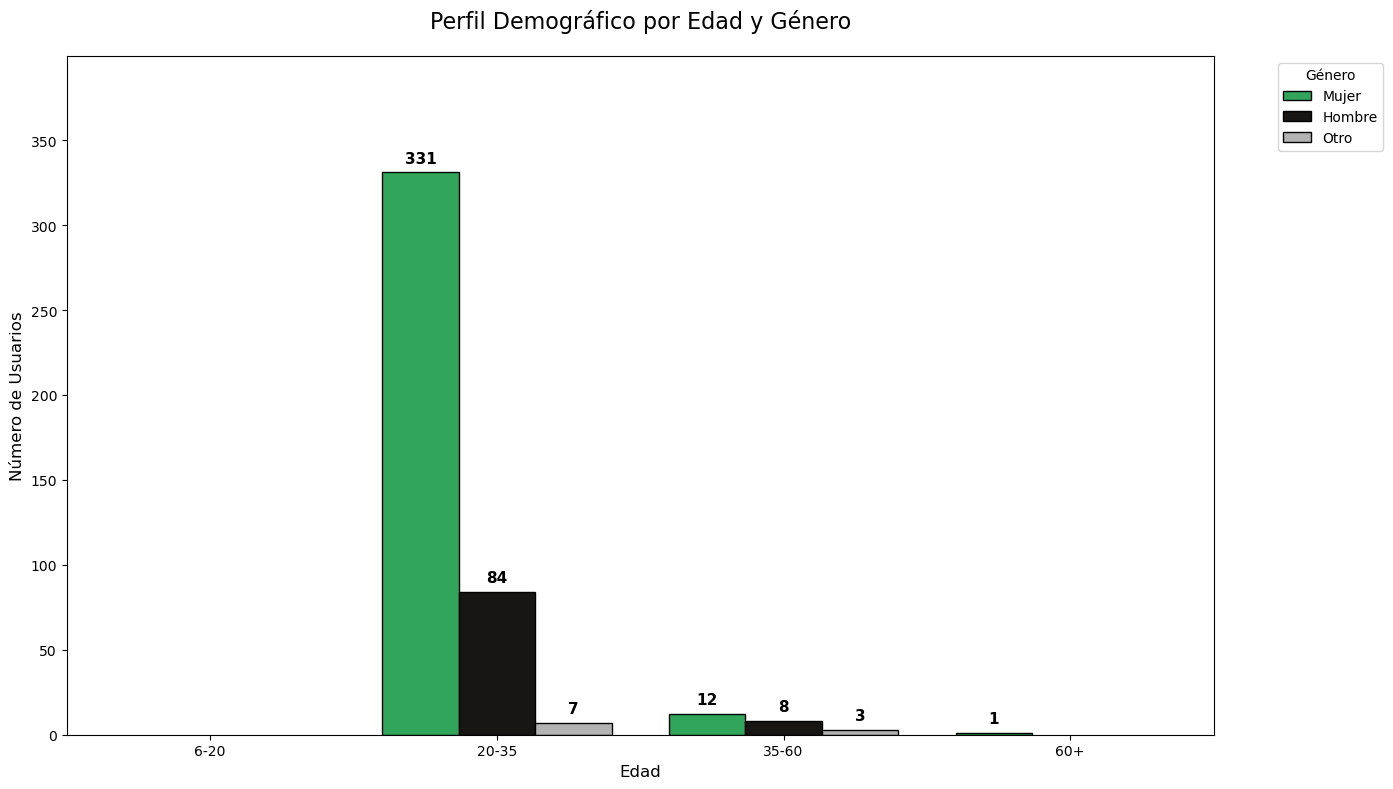

In [4]:
orden_edades = ['6-20', '20-35', '35-60', '60+']
colores_spotify = ['#1DB954', '#191414', '#B3B3B3'] 

plt.figure(figsize=(14, 8))
ax = sns.countplot(
    data=Spotify_limpio, 
    x='EDAD', 
    hue='GENERO', 
    order=orden_edades, 
    palette=colores_spotify,
    edgecolor='black')

for container in ax.containers:
    ax.bar_label(container, fontsize=11, fontweight='bold', padding=5)

plt.title('Perfil Demográfico por Edad y Género', fontsize=16, pad=20)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Número de Usuarios', fontsize=12)

plt.legend(title='Género', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.ylim(0, ax.get_ylim()[1] * 1.15)

plt.tight_layout()
plt.show()

### Antiguedad

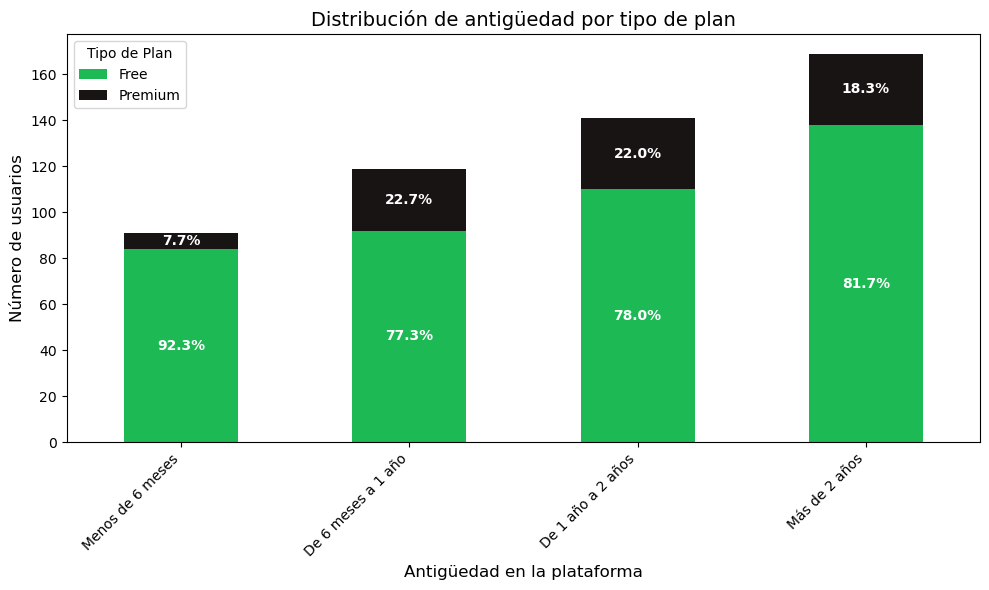

In [5]:
orden_temporal = [
    "Menos de 6 meses", 
    "De 6 meses a 1 año", 
    "De 1 año a 2 años", 
    "Más de 2 años"
]

Spotify_limpio["ANTIGUEDAD"] = pd.Categorical(
    Spotify_limpio["ANTIGUEDAD"], 
    categories=orden_temporal, 
    ordered=True
)

tabla_frecuencia = pd.crosstab(Spotify_limpio["ANTIGUEDAD"], Spotify_limpio["SUSCRIPCION"])


tabla_porcentajes = pd.crosstab(Spotify_limpio["ANTIGUEDAD"], Spotify_limpio["SUSCRIPCION"], normalize='index') * 100

ax = tabla_frecuencia.plot(kind="bar", stacked=True, figsize=(10,6), color=["#1DB954", "#191414"]) # Colores estilo Spotify

plt.title("Distribución de antigüedad por tipo de plan", fontsize=14)
plt.xlabel("Antigüedad en la plataforma", fontsize=12)
plt.ylabel("Número de usuarios", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Tipo de Plan")


for i in range(len(tabla_frecuencia)):
    acumulado = 0
    for col in tabla_frecuencia.columns:
        valor = tabla_frecuencia.loc[tabla_frecuencia.index[i], col]
        porcentaje = tabla_porcentajes.loc[tabla_porcentajes.index[i], col]
        
        if valor > 0: 
  
            ax.text(i, acumulado + (valor/2), f"{porcentaje.round(1)}%", 
                    ha="center", va="center", color="white", fontweight="bold")
            acumulado += valor

plt.tight_layout()
plt.show()

## HÁBITOS DE CONSUMO Y PREFERENCIAS (MÚSICA/PODCAST)

### Género musical favorito

C:\Users\Usuario\AppData\Local\Temp\ipykernel_3732\337810726.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_generos.values,


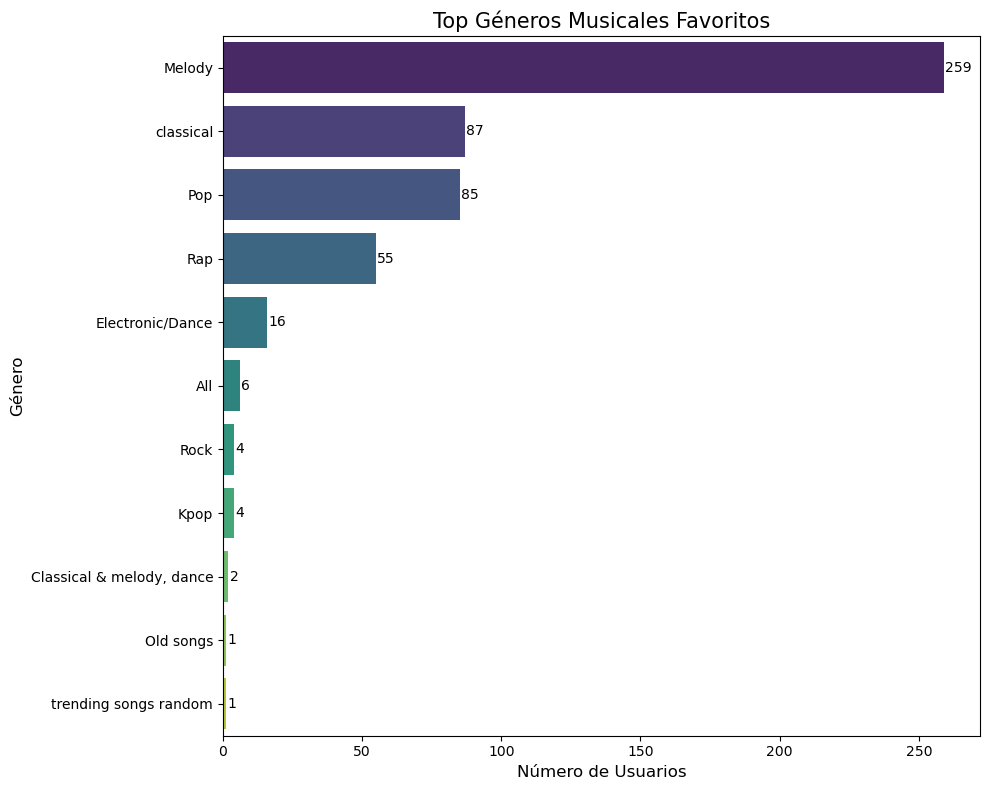

In [15]:
conteo_generos = Spotify_limpio['GENERO_FAV_MUSICA'].value_counts()

plt.figure(figsize=(10, 8))

sns.barplot(x=conteo_generos.values, 
            y=conteo_generos.index, 
            palette='viridis')

plt.title('Top Géneros Musicales Favoritos', fontsize=15)
plt.xlabel('Número de Usuarios', fontsize=12)
plt.ylabel('Género', fontsize=12)

for i, v in enumerate(conteo_generos.values):
    plt.text(v + 0.5, i, str(v), color='black', va='center')

plt.tight_layout()
plt.show()

### Género podcast favorito

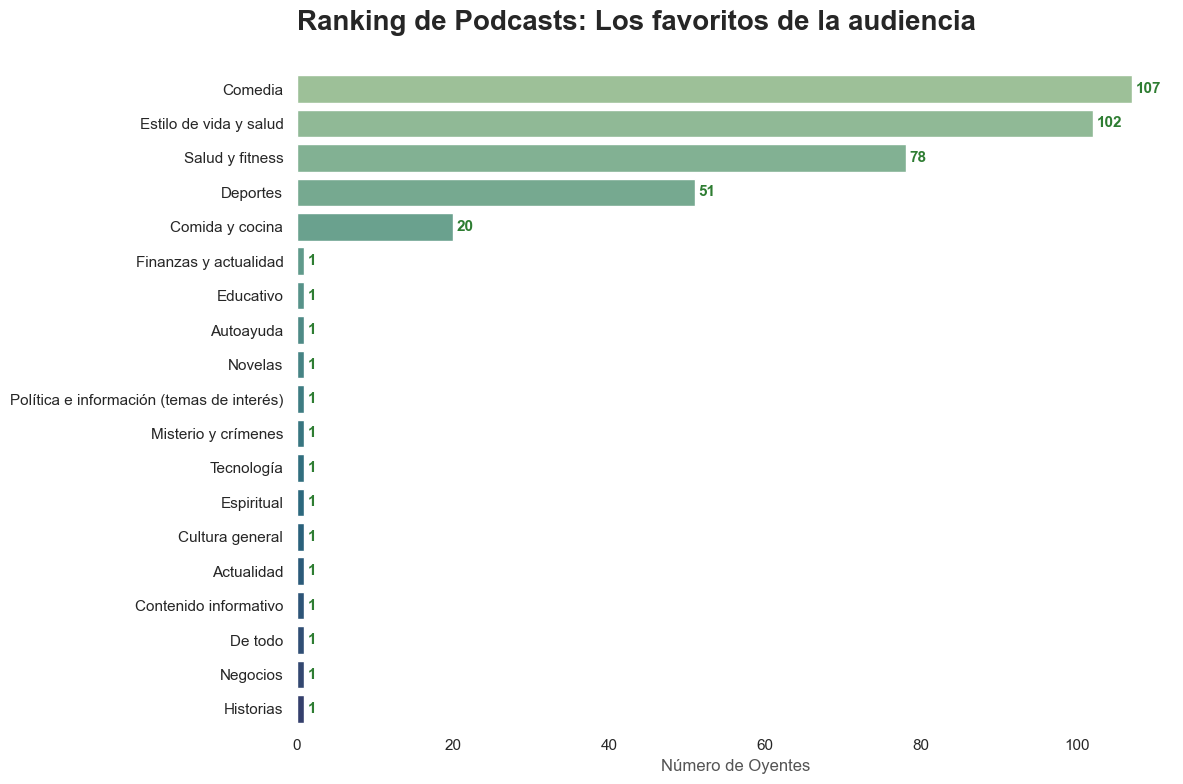

In [16]:

df_filtrado = Spotify_limpio[Spotify_limpio['GENERO_FAV_POD'] != 'No aplicable/Ninguno'].copy()
conteo_podcasts = df_filtrado['GENERO_FAV_POD'].value_counts()


sns.set_theme(style="white") 
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    x=conteo_podcasts.values, 
    y=conteo_podcasts.index, 
    palette='crest', 
    hue=conteo_podcasts.index,
    legend=False
)


plt.title('Ranking de Podcasts: Los favoritos de la audiencia', 
          fontsize=20, pad=30, fontweight='bold', loc='left') # Verde Spotify
plt.xlabel('Número de Oyentes', fontsize=12, color='#555555')
plt.ylabel('') 


for i, v in enumerate(conteo_podcasts.values):
    ax.text(v + 0.5, i, f'{int(v)}', va='center', fontsize=11, fontweight='bold', color='#2e7d32')


sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

### Género musical favorito según rango de edad

<Figure size 1400x800 with 0 Axes>

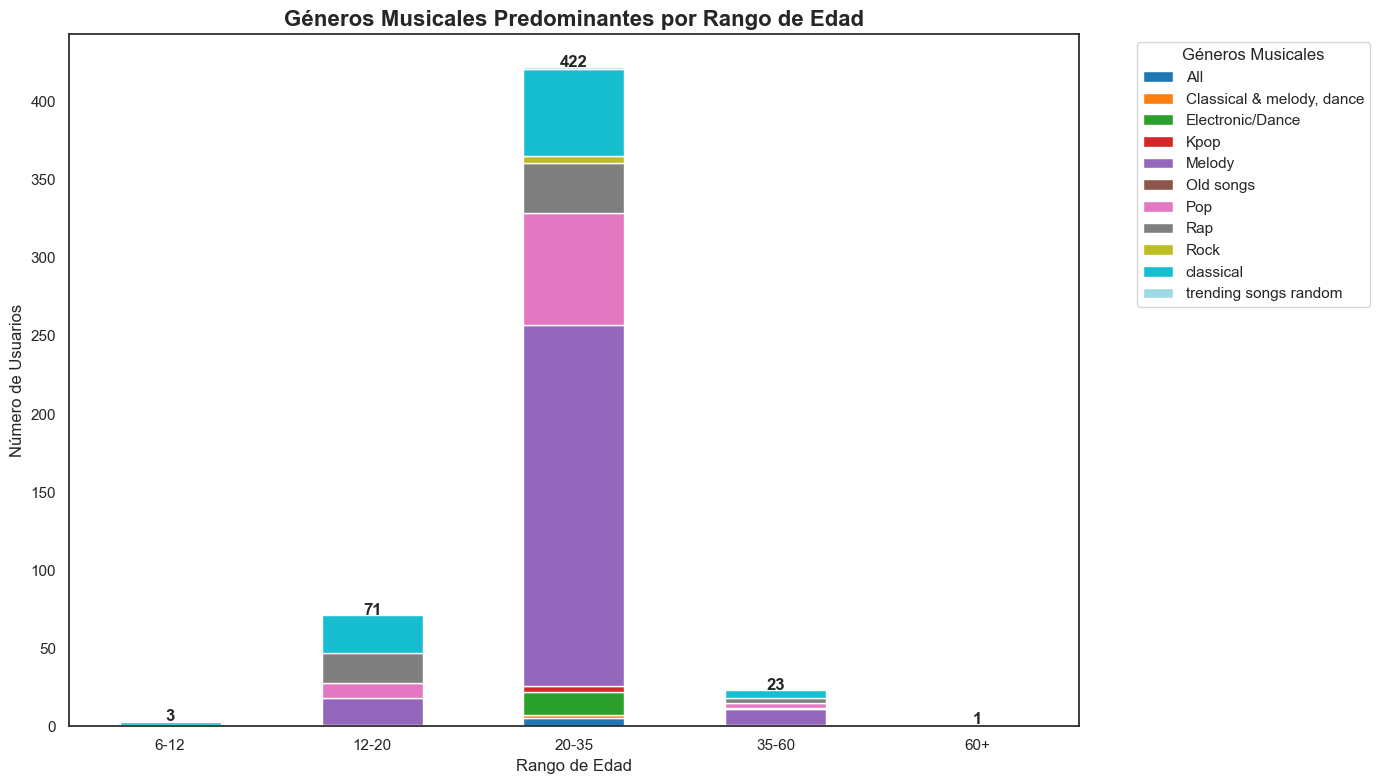


--- TOP 3 GÉNEROS POR EDAD ---

Edad 6-12:
 - classical: 2 usuarios
 - Rap: 1 usuarios
 - All: 0 usuarios

Edad 12-20:
 - classical: 24 usuarios
 - Rap: 19 usuarios
 - Melody: 17 usuarios

Edad 20-35:
 - Melody: 231 usuarios
 - Pop: 72 usuarios
 - classical: 56 usuarios

Edad 35-60:
 - Melody: 10 usuarios
 - classical: 5 usuarios
 - Pop: 3 usuarios

Edad 60+:
 - Melody: 1 usuarios
 - All: 0 usuarios
 - Classical & melody, dance: 0 usuarios


In [17]:
orden_edades = ['6-12','12-20', '20-35', '35-60', '60+']


tabla_generos = pd.crosstab(Spotify_limpio['EDAD'], Spotify_limpio['GENERO_FAV_MUSICA'])


tabla_generos = tabla_generos.reindex(orden_edades)

plt.figure(figsize=(14, 8))
ax = tabla_generos.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab20', edgecolor='white')


plt.title('Géneros Musicales Predominantes por Rango de Edad', fontsize=16, fontweight='bold')
plt.ylabel('Número de Usuarios', fontsize=12)
plt.xlabel('Rango de Edad', fontsize=12)
plt.xticks(rotation=0) 


for i, total in enumerate(tabla_generos.sum(axis=1)):
    plt.text(i, total + 0.5, str(int(total)), ha='center', fontweight='bold')

plt.legend(title='Géneros Musicales', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


print("\n--- TOP 3 GÉNEROS POR EDAD ---")
for edad in orden_edades:
    if edad in tabla_generos.index:
        top_3 = tabla_generos.loc[edad].sort_values(ascending=False).head(3)
        print(f"\nEdad {edad}:")
        for genero, cant in top_3.items():
            print(f" - {genero}: {cant} usuarios")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_3732\4226568782.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


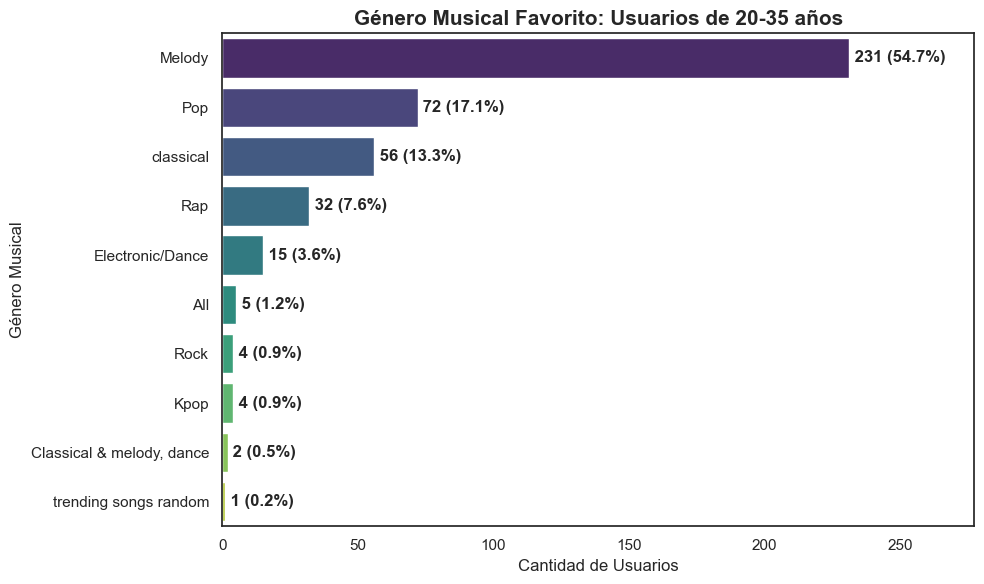

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtramos y contamos
datos_20_35 = Spotify_limpio[Spotify_limpio['EDAD'] == '20-35']
conteo_generos = datos_20_35['GENERO_FAV_MUSICA'].value_counts()

# 2. Creamos el gráfico de barras horizontales (mucho más legible)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=conteo_generos.values, 
    y=conteo_generos.index, 
    palette='viridis'
)

# 3. Añadimos el número exacto y el porcentaje al final de cada barra
total = conteo_generos.sum()
for i, v in enumerate(conteo_generos.values):
    porcentaje = (v / total) * 100
    ax.text(v + 0.3, i, f' {int(v)} ({porcentaje:.1f}%)', va='center', fontweight='bold')

plt.title('Género Musical Favorito: Usuarios de 20-35 años', fontsize=15, fontweight='bold')
plt.xlabel('Cantidad de Usuarios')
plt.ylabel('Género Musical')

# Ajustamos límites para que no se corten los textos
plt.xlim(0, conteo_generos.max() * 1.2) 
plt.tight_layout()
plt.show()

### Género podcast favorito según rango de edad

C:\Users\Usuario\AppData\Local\Temp\ipykernel_3732\2992579521.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


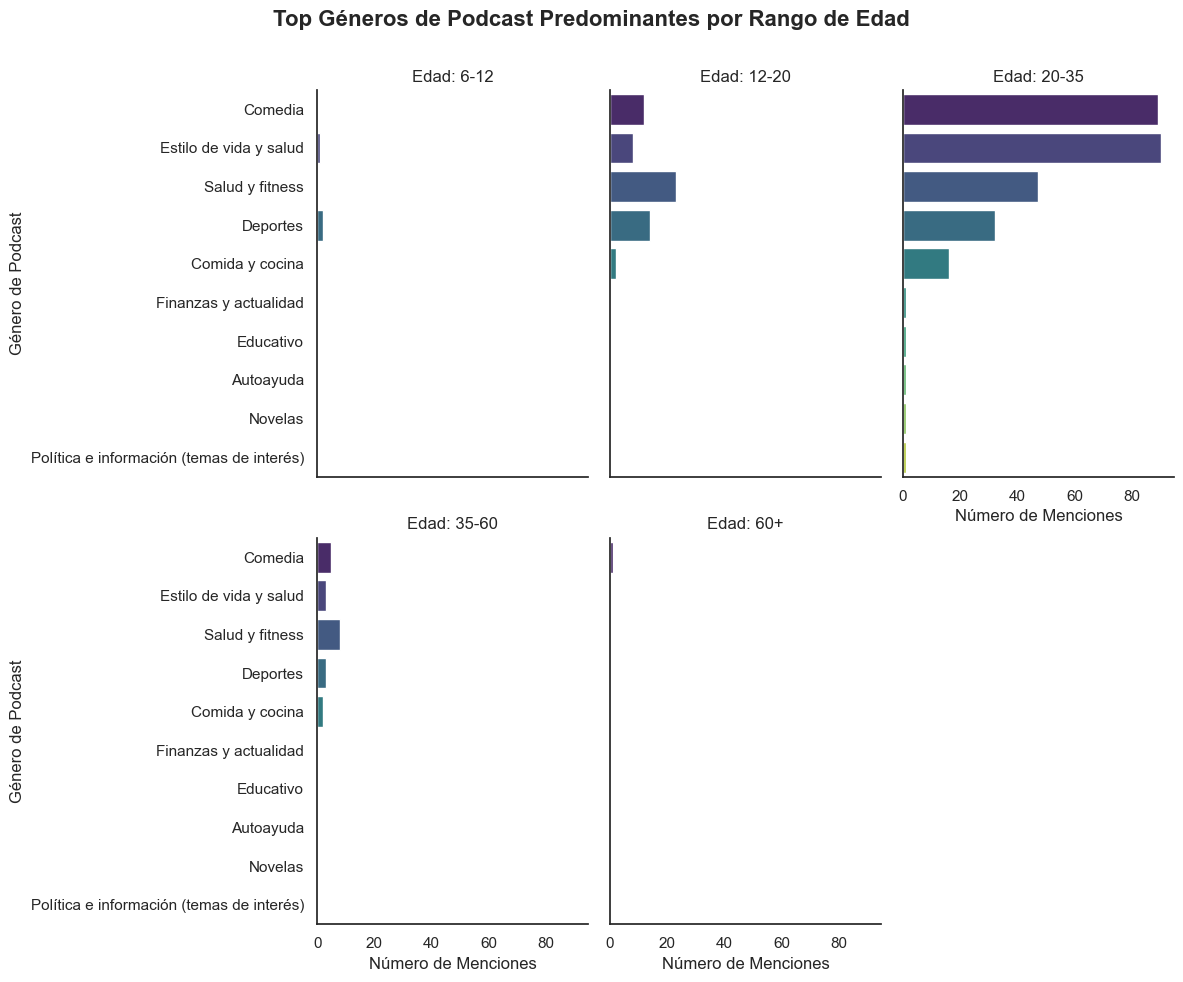


--- RESUMEN DE PODCASTS POR EDAD ---

>>> EDAD 6-12:
    - Deportes: 2 menciones
    - Estilo de vida y salud: 1 menciones

>>> EDAD 12-20:
    - Salud y fitness: 23 menciones
    - Deportes: 14 menciones
    - Comedia: 12 menciones

>>> EDAD 20-35:
    - Estilo de vida y salud: 90 menciones
    - Comedia: 89 menciones
    - Salud y fitness: 47 menciones

>>> EDAD 35-60:
    - Salud y fitness: 8 menciones
    - Comedia: 5 menciones
    - Deportes: 3 menciones

>>> EDAD 60+:
    - Comedia: 1 menciones


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparación de datos (Explode de Podcast)
df_pod_final = Spotify_limpio.copy()
# Separamos por coma (con o sin espacio)
df_pod_final['GENERO_FAV_POD'] = df_pod_final['GENERO_FAV_POD'].str.split(r',\s*')
df_pod_final = df_pod_final.explode('GENERO_FAV_POD')
df_pod_final['GENERO_FAV_POD'] = df_pod_final['GENERO_FAV_POD'].str.strip().str.capitalize()

# Eliminamos filas donde no haya datos de podcast (opcional)
df_pod_final = df_pod_final[df_pod_final['GENERO_FAV_POD'] != 'No aplicable/ninguno']

# 2. Definimos el orden de las edades
orden_edades = ['6-12', '12-20', '20-35', '35-60', '60+']

# 3. Creamos la visualización
# Usaremos un FacetGrid para ver un gráfico por cada rango de edad
# Esto permite ver los géneros predominantes sin que se mezclen
g = sns.catplot(
    data=df_pod_final, 
    y="GENERO_FAV_POD", 
    col="EDAD", 
    col_order=orden_edades,
    kind="count", 
    height=5, 
    aspect=0.8,
    palette="viridis",
    col_wrap=3, # Organiza en 3 columnas para que no sea una línea infinita
    order=df_pod_final['GENERO_FAV_POD'].value_counts().index[:10] # Top 10 géneros globales para comparar
)

# 4. Ajustes estéticos
g.set_axis_labels("Número de Menciones", "Género de Podcast")
g.set_titles("Edad: {col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Top Géneros de Podcast Predominantes por Rango de Edad', fontsize=16, fontweight='bold')

plt.show()

# 5. Resumen en texto (para confirmar que los datos son de Podcast)
print("\n--- RESUMEN DE PODCASTS POR EDAD ---")
for edad in orden_edades:
    if edad in df_pod_final['EDAD'].values:
        print(f"\n>>> EDAD {edad}:")
        top = df_pod_final[df_pod_final['EDAD'] == edad]['GENERO_FAV_POD'].value_counts().head(3)
        for gen, count in top.items():
            print(f"    - {gen}: {count} menciones")

### Género musical favorito según género del usuario

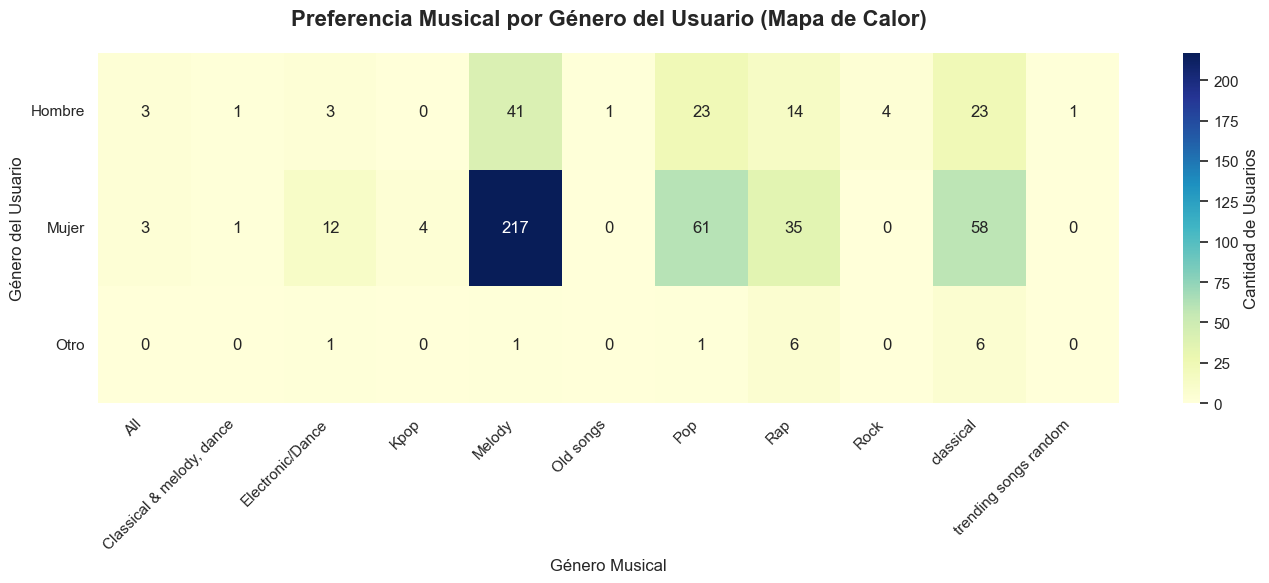

In [20]:
tabla_musica_genero = pd.crosstab(Spotify_limpio['GENERO'], Spotify_limpio['GENERO_FAV_MUSICA'])

plt.figure(figsize=(14, 6))
sns.heatmap(tabla_musica_genero, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={'label': 'Cantidad de Usuarios'})

plt.title('Preferencia Musical por Género del Usuario (Mapa de Calor)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Género Musical', fontsize=12)
plt.ylabel('Género del Usuario', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Género podcast favorito según género del usuario

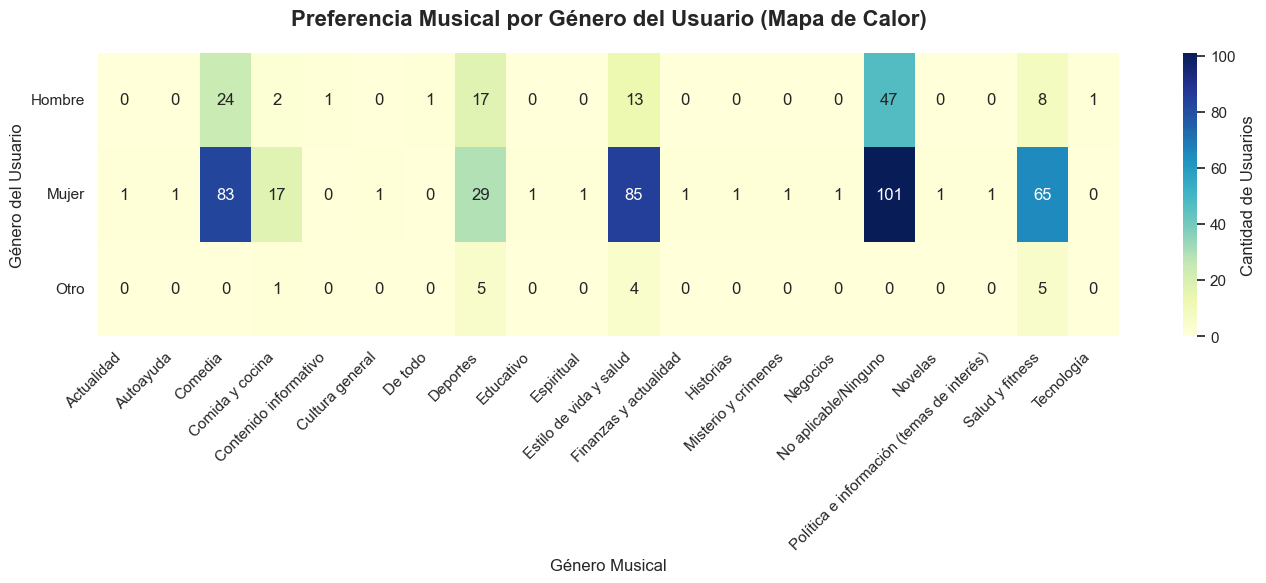

In [21]:
tabla_musica_genero = pd.crosstab(Spotify_limpio['GENERO'], Spotify_limpio['GENERO_FAV_POD'])

plt.figure(figsize=(14, 6))
sns.heatmap(tabla_musica_genero, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={'label': 'Cantidad de Usuarios'})

plt.title('Preferencia Musical por Género del Usuario (Mapa de Calor)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Género Musical', fontsize=12)
plt.ylabel('Género del Usuario', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

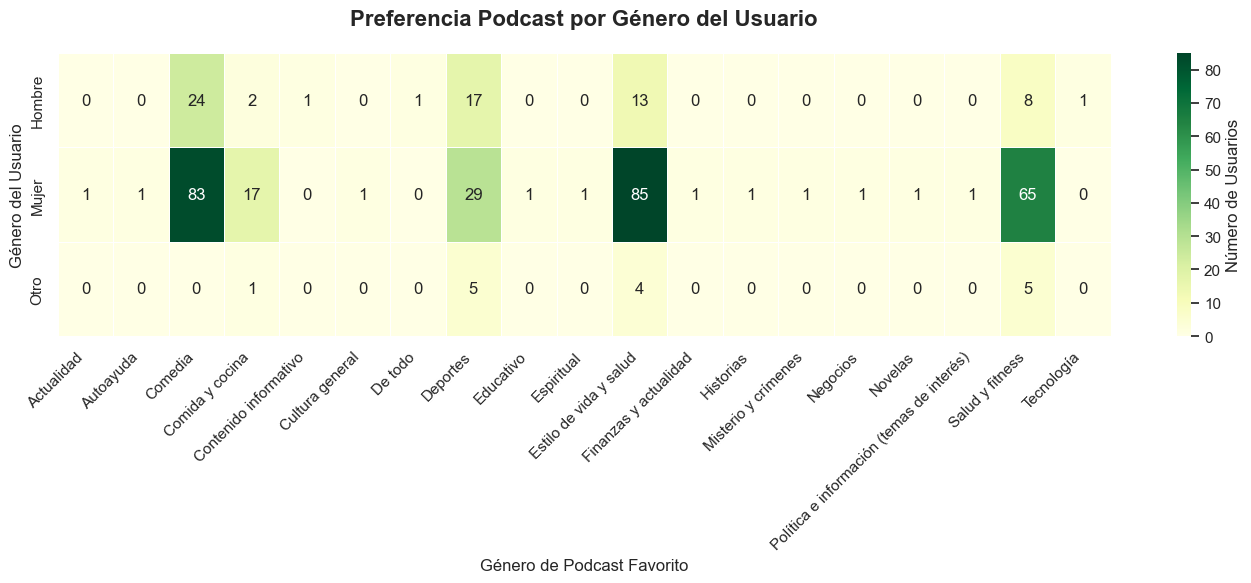

In [22]:
df_filtrado = Spotify_limpio[Spotify_limpio['GENERO_FAV_POD'] != 'No aplicable/Ninguno'].copy()

tabla_frecuencias = pd.crosstab(df_filtrado['GENERO'], df_filtrado['GENERO_FAV_POD'])

plt.figure(figsize=(14, 6))

sns.heatmap(tabla_frecuencias, 
            annot=True, 
            fmt='d', 
            cmap='YlGn', 
            linewidths=0.5,
            cbar_kws={'label': 'Número de Usuarios'})

plt.title('Preferencia Podcast por Género del Usuario', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Género de Podcast Favorito', fontsize=12)
plt.ylabel('Género del Usuario', fontsize=12)

plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

### Relación entre Franja Horaria y Momento Musical

In [23]:
tabla_frecuencias = pd.crosstab(df_explode['MOMENTO_MUSICA'], df_explode['FRANJA_HORARIA'])


orden_dia = ['Mañana', 'Mediodía', 'Tarde', 'Noche']

columnas_existentes = [c for c in orden_dia if c in tabla_frecuencias.columns]
tabla_frecuencias = tabla_frecuencias[columnas_existentes]

plt.figure(figsize=(12, 8))
sns.heatmap(
    tabla_frecuencias, 
    annot=True,  
    fmt="d",     
    cmap="YlGnBu", 
    linewidths=.5 
)

plt.title("Intensidad de Momentos Musicales por Franja Horaria", fontsize=14, fontweight="bold")
plt.xlabel("Franja Horaria")
plt.ylabel("Momento Musical")
plt.tight_layout()
plt.show()

NameError: name 'df_explode' is not defined

### ¿Cómo encuentran música nueva los usuarios?

C:\Users\Usuario\AppData\Local\Temp\ipykernel_3732\872624977.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


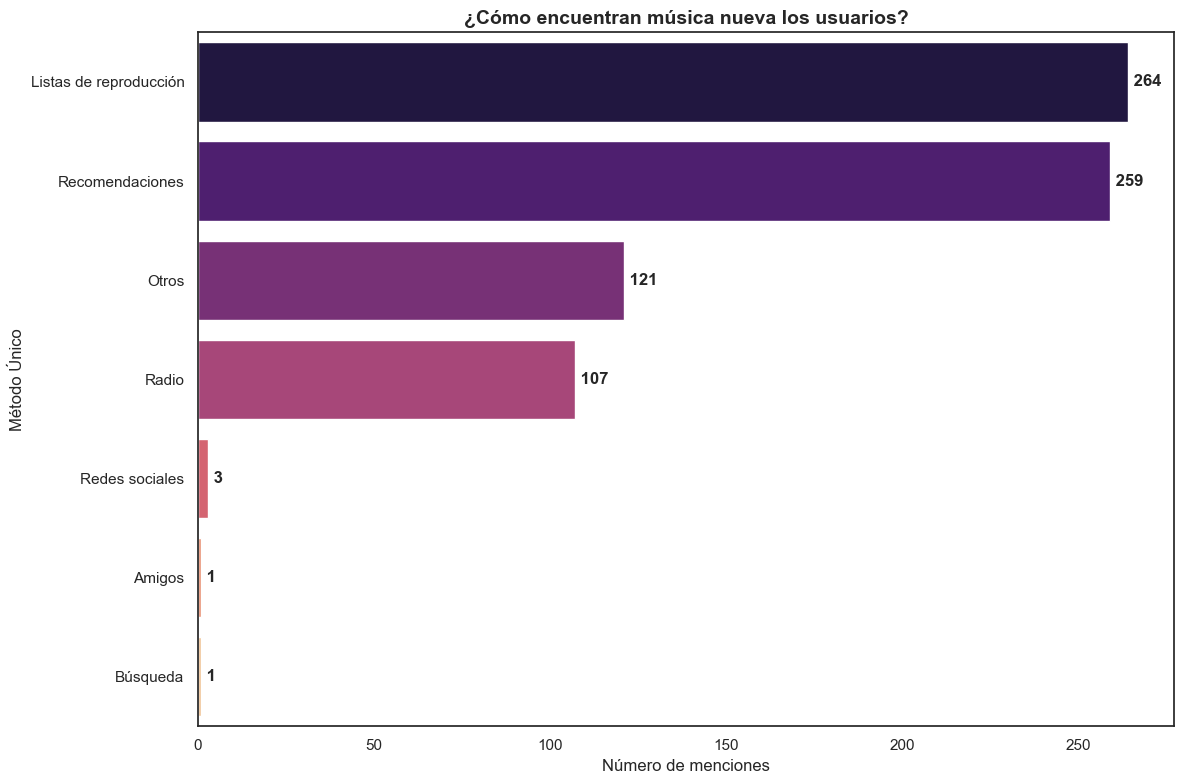

In [24]:
df_descubre = Spotify_limpio.copy()

df_descubre['DESCUBRIMIENTO'] = df_descubre['DESCUBRIMIENTO'].str.split(r',\s*')

df_descubre = df_descubre.explode('DESCUBRIMIENTO')

df_descubre['DESCUBRIMIENTO'] = df_descubre['DESCUBRIMIENTO'].str.strip().str.capitalize()

df_descubre = df_descubre[df_descubre['DESCUBRIMIENTO'] != '']

plt.figure(figsize=(12, 8))
conteo_descubrimiento = df_descubre['DESCUBRIMIENTO'].value_counts()

ax = sns.barplot(
    x=conteo_descubrimiento.values, 
    y=conteo_descubrimiento.index, 
    palette="magma"
)

for i, v in enumerate(conteo_descubrimiento.values):
    ax.text(v + 0.3, i, f' {int(v)}', va='center', fontweight='bold')

plt.title("¿Cómo encuentran música nueva los usuarios?", fontsize=14, fontweight="bold")
plt.xlabel("Número de menciones")
plt.ylabel("Método Único")

plt.tight_layout()
plt.show()

### Contenido preferido por los usuarios

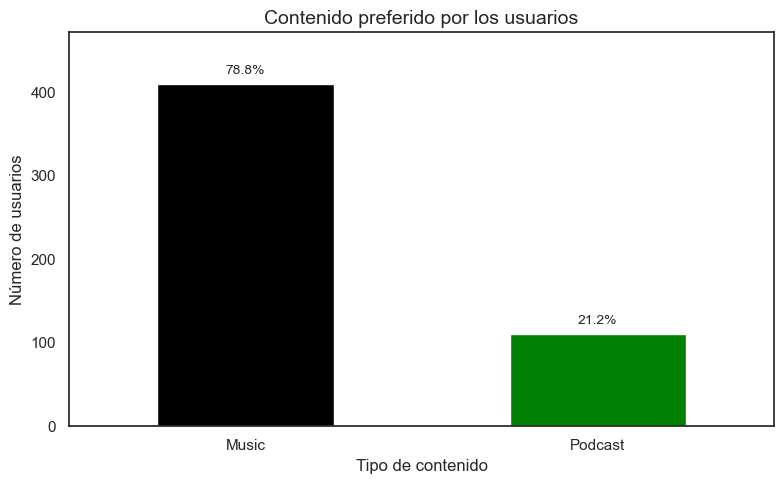

In [25]:
conteos = Spotify_limpio["CONTENIDO_PREFERIDO"].value_counts()

porcentajes = (Spotify_limpio["CONTENIDO_PREFERIDO"].value_counts(normalize=True) * 100).round(1)

if len(conteos) == 2:
    colores = ["black", "green"]
else:
    colores = ["black", "green", "gray"]

plt.figure(figsize=(8,5))
ax = conteos.plot(kind="bar", color=colores[:len(conteos)])

plt.title("Contenido preferido por los usuarios", fontsize=14)
plt.xlabel("Tipo de contenido", fontsize=12)
plt.ylabel("Número de usuarios", fontsize=12)
plt.xticks(rotation=0)

ax.set_ylim(0, conteos.max() * 1.15)

for i, (v, p) in enumerate(zip(conteos.values, porcentajes.values)):
    ax.text(i, v + conteos.max()*0.02, f"{p}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

### Porcentaje de suscripción según contenido preferido

<Figure size 1200x700 with 0 Axes>

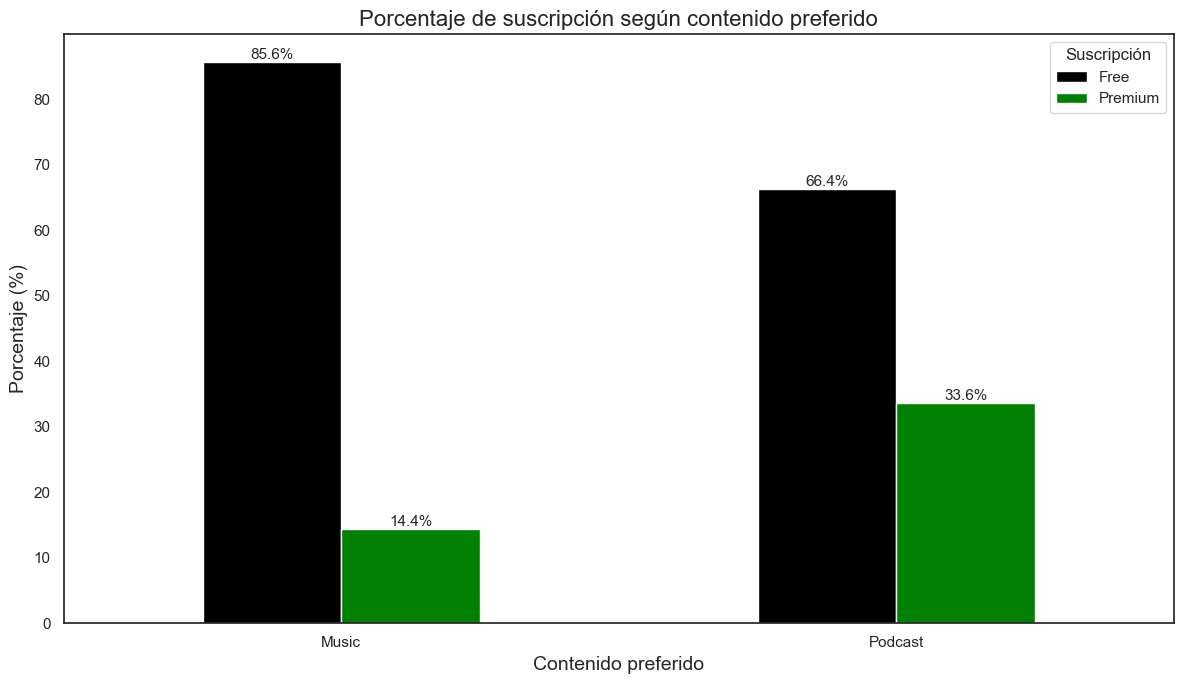

In [26]:
tabla = pd.crosstab(Spotify_limpio["CONTENIDO_PREFERIDO"], Spotify_limpio["SUSCRIPCION"])

tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12,7)) 
ax = tabla_pct.plot(kind="bar", figsize=(12,7), color=["black", "green"]) 

plt.title("Porcentaje de suscripción según contenido preferido", fontsize=16)
plt.xlabel("Contenido preferido", fontsize=14)
plt.ylabel("Porcentaje (%)", fontsize=14)
plt.xticks(rotation=0)
plt.legend(title="Suscripción")

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height:.1f}%",            
            (p.get_x() + p.get_width() / 2, height),  
            ha='center', va='bottom', fontsize=11
        )

plt.tight_layout()
plt.show()

## VALORACION_RECOMENDACIONES

### ¿Qué tan satisfechos están los usuarios con las recomendaciones?

Promedio de recomendaciones: 3.50


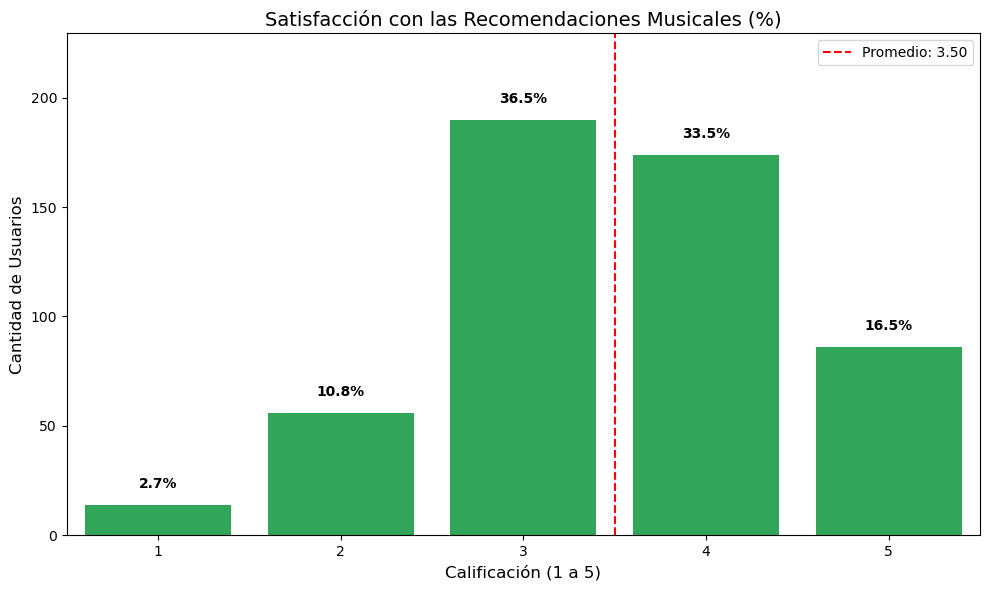

In [6]:
print(f"Promedio de recomendaciones: {Spotify_limpio['VALORACION_RECOMENDACIONES'].mean():.2f}")

total_usuarios = len(Spotify_limpio)
media_satisfaccion = Spotify_limpio['VALORACION_RECOMENDACIONES'].mean()

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=Spotify_limpio, x='VALORACION_RECOMENDACIONES', color='#1DB954')

for p in ax.patches:
    porcentaje = f'{(100 * p.get_height() / total_usuarios):.1f}%'
    ax.annotate(porcentaje, 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 15),
                textcoords = 'offset points',
                rotation = 0,
                fontsize = 10,
                fontweight = 'bold')

plt.axvline(x=media_satisfaccion - 1, color='red', linestyle='--', 
            label=f'Promedio: {media_satisfaccion:.2f}')

plt.title('Satisfacción con las Recomendaciones Musicales (%)', fontsize=14)
plt.xlabel('Calificación (1 a 5)', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.ylim(0, ax.get_ylim()[1] * 1.15) 

plt.legend()
plt.tight_layout()
plt.show()

### ¿Qué tan satisfechos están los usuarios con las recomendaciones según su género?

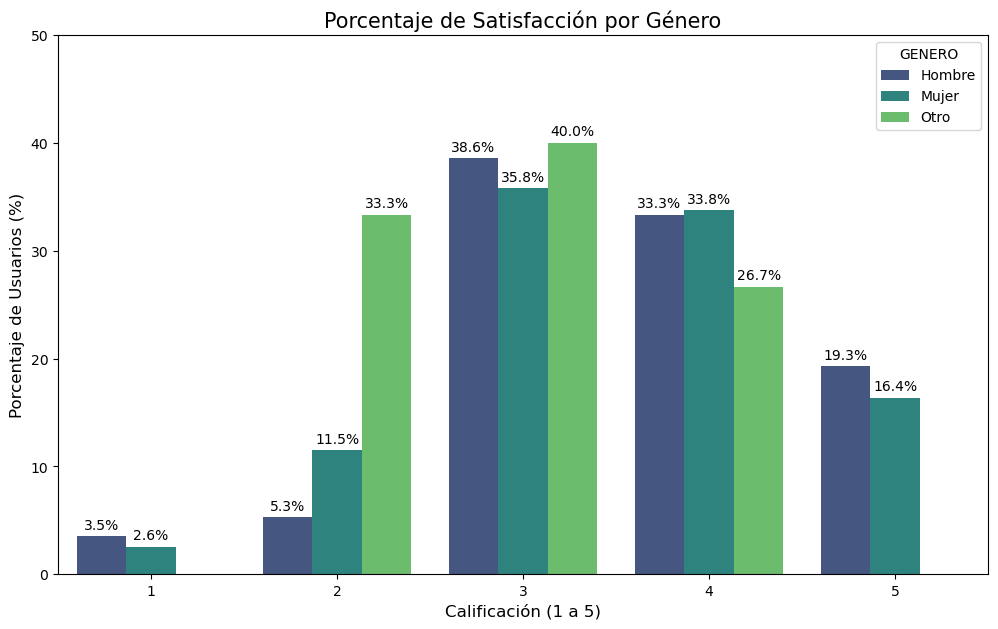

In [7]:
df_pct = Spotify_limpio.groupby('GENERO')['VALORACION_RECOMENDACIONES'].value_counts(normalize=True).rename('PORCENTAJE').reset_index()
df_pct['PORCENTAJE'] = df_pct['PORCENTAJE'] * 100
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=df_pct, 
    x='VALORACION_RECOMENDACIONES', 
    y='PORCENTAJE', 
    hue='GENERO', 
    palette='viridis')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title('Porcentaje de Satisfacción por Género', fontsize=15)
plt.xlabel('Calificación (1 a 5)', fontsize=12)
plt.ylabel('Porcentaje de Usuarios (%)', fontsize=12)
plt.ylim(0, df_pct['PORCENTAJE'].max() + 10)

plt.show()

### ¿Qué tan satisfechos están los usuarios con las recomendaciones según su edad?

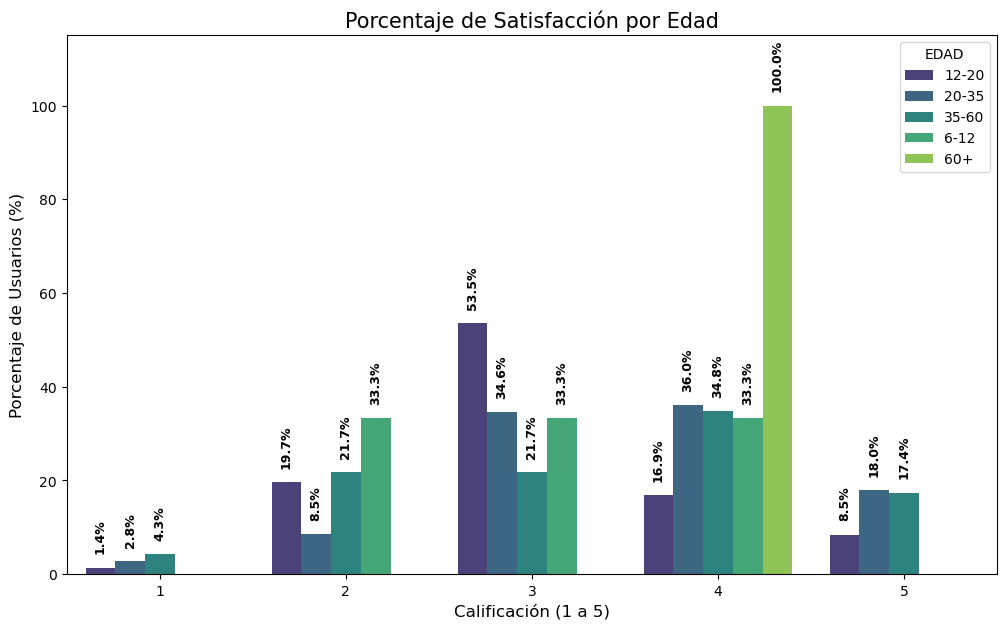

In [8]:


df_pct = Spotify_limpio.groupby('EDAD')['VALORACION_RECOMENDACIONES'].value_counts(normalize=True).rename('PORCENTAJE').reset_index()
df_pct['PORCENTAJE'] = df_pct['PORCENTAJE'] * 100 

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=df_pct, 
    x='VALORACION_RECOMENDACIONES', 
    y='PORCENTAJE', 
    hue='EDAD', 
    palette='viridis')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=10, rotation=90, fontsize=9, fontweight='bold')

plt.title('Porcentaje de Satisfacción por Edad', fontsize=15)
plt.xlabel('Calificación (1 a 5)', fontsize=12)
plt.ylabel('Porcentaje de Usuarios (%)', fontsize=12)
plt.ylim(0, df_pct['PORCENTAJE'].max() + 15)

plt.show()

## SATISFACCION_PODCAST

### ¿Qué tan satisfechos están los usuarios con la disponibilidad y variabilidad de los podcast?

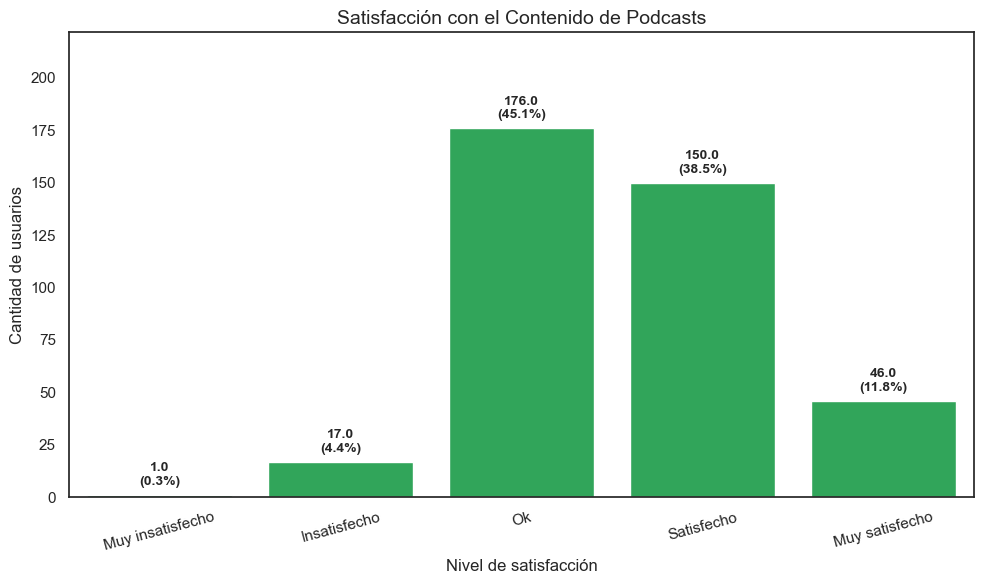

In [39]:
# Filtrar solo usuarios que consumen podcasts
df_pod = Spotify_limpio[Spotify_limpio["CONSUME_PODCAST"] == True]
orden_satisfaccion = [
    "Muy insatisfecho",
    "Insatisfecho",
    "Ok",
    "Satisfecho",
    "Muy satisfecho"
]

plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=df_pod,
    x='SATISFACCION_POD',
    order=orden_satisfaccion,
    color='#1DB954'
)

total_usuarios_pod = len(df_pod)
for p in ax.patches:
    conteo = p.get_height()
    porcentaje = f'{100 * conteo / total_usuarios_pod:.1f}%'
    ax.annotate(
        f'{conteo}\n({porcentaje})',
        (p.get_x() + p.get_width() / 2., conteo),
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Satisfacción con el Contenido de Podcasts', fontsize=14)
plt.xlabel('Nivel de satisfacción', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.xticks(rotation=15)
plt.ylim(0, ax.get_ylim()[1] * 1.2)
plt.tight_layout()
plt.show()

### ¿Qué tan satisfechos están los usuarios con la disponibilidad y variabilidad de los podcast según su género?

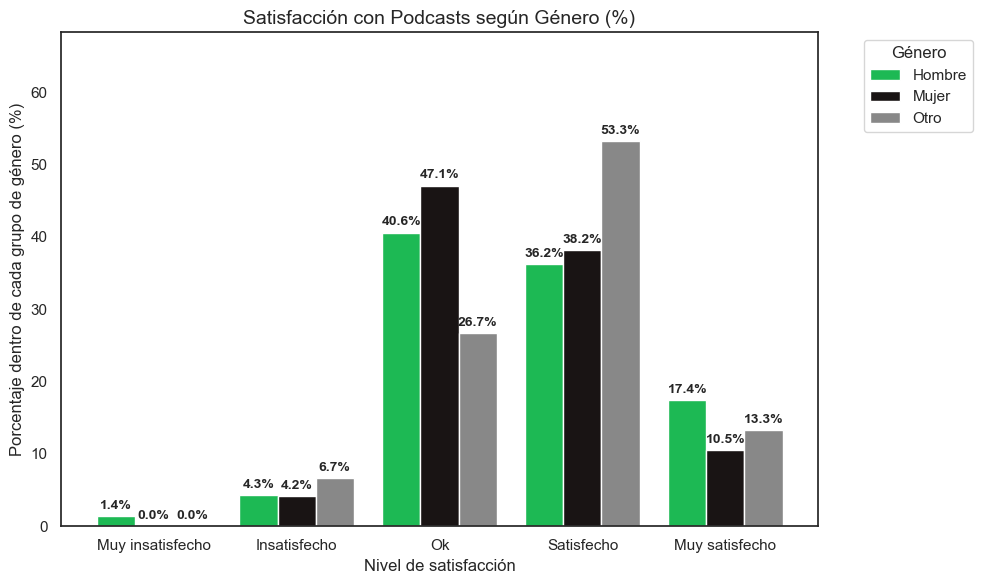

In [45]:
import matplotlib.pyplot as plt


df_pod = Spotify_limpio[Spotify_limpio["CONSUME_PODCAST"] == True]


tabla_pct_genero = pd.crosstab(
    pd.Categorical(df_pod["SATISFACCION_POD"], 
                   categories=["Muy insatisfecho","Insatisfecho","Ok","Satisfecho","Muy satisfecho"], 
                   ordered=True),
    df_pod["GENERO"],
    normalize='columns'
).round(3) * 100


colores_genero = ["#1DB954", "#191414", "#888888"][:tabla_pct_genero.shape[1]]

# Gráfico
ax = tabla_pct_genero.plot(
    kind="bar",
    figsize=(10, 6),
    color=colores_genero,
    width=0.8  
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3,
        rotation=0,  
        fontsize=10,
        fontweight='bold'
    )

plt.title("Satisfacción con Podcasts según Género (%)", fontsize=14)
plt.xlabel("Nivel de satisfacción", fontsize=12)
plt.ylabel("Porcentaje dentro de cada grupo de género (%)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Género", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.ylim(0, tabla_pct_genero.values.max() + 15)

plt.tight_layout()
plt.show()

### ¿Qué tan satisfechos están los usuarios con la disponibilidad y variabilidad de los podcast según su edad?

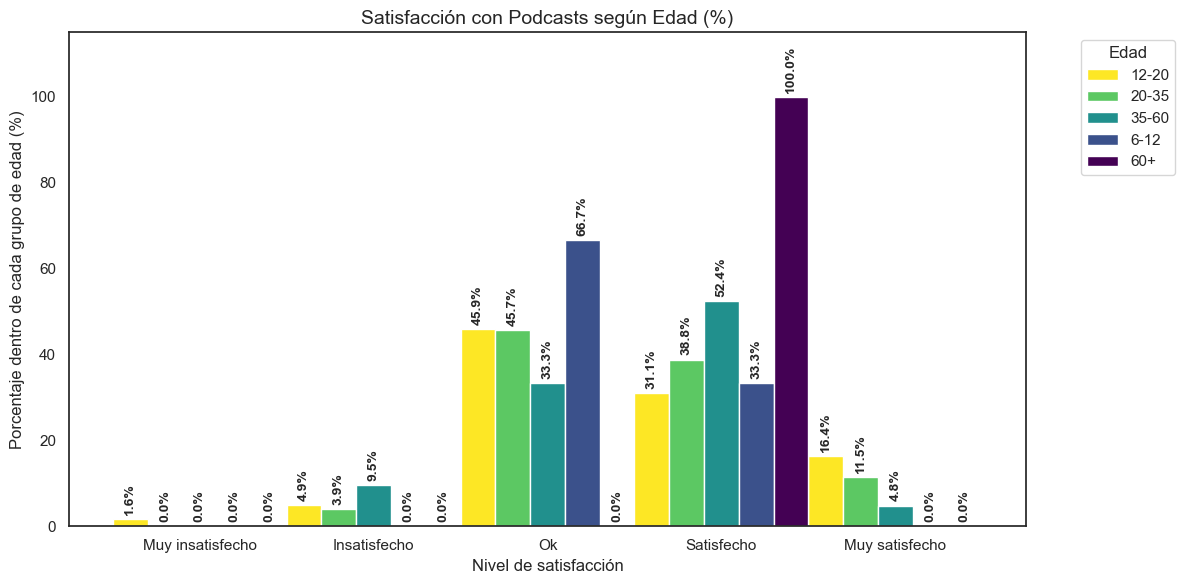

In [49]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_pod = Spotify_limpio[Spotify_limpio["CONSUME_PODCAST"] == True]

orden_satisfaccion = ["Muy insatisfecho","Insatisfecho","Ok","Satisfecho","Muy satisfecho"]
tabla_pct_edad = pd.crosstab(
    pd.Categorical(df_pod["SATISFACCION_POD"], categories=orden_satisfaccion, ordered=True),
    df_pod["EDAD"],
    normalize='columns'
).round(3) * 100

colores = plt.cm.viridis_r(np.linspace(0,1,tabla_pct_edad.shape[1]))
ax = tabla_pct_edad.plot(
    kind="bar",
    figsize=(12, 6),
    color=colores,
    width=1 
)
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3,
        rotation=90,  # horizontal
        fontsize=10,
        fontweight='bold'
    )

plt.title("Satisfacción con Podcasts según Edad (%)", fontsize=14)
plt.xlabel("Nivel de satisfacción", fontsize=12)
plt.ylabel("Porcentaje dentro de cada grupo de edad (%)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Edad", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, tabla_pct_edad.values.max() + 15)
plt.tight_layout()
plt.show()

## FIDELIZACIÓN Y CONVERSIÓN

### Conteo y Porcentaje de usuarios según su suscripción/¿quiere pagar?

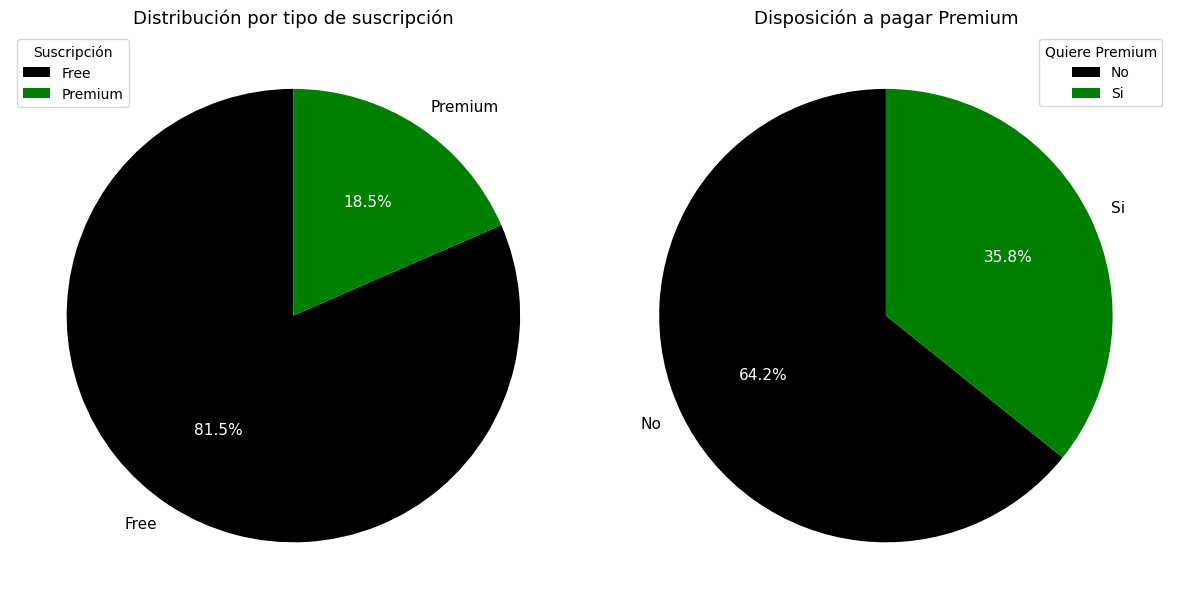

In [9]:
suscripcion_counts = Spotify_limpio["SUSCRIPCION"].value_counts()
quiere_premium_counts = Spotify_limpio["QUIERE_PREMIUM"].value_counts()
colores = ["black", "green"]
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
wedges1, texts1, autotexts1 = axes[0].pie(
    suscripcion_counts,
    labels=suscripcion_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colores,
    textprops={"fontsize": 11})
axes[0].set_title("Distribución por tipo de suscripción", fontsize=13)

for t in autotexts1:
    t.set_color("white")
    t.set_fontsize(11)

axes[0].legend(
    wedges1,
    suscripcion_counts.index,
    title="Suscripción",
    loc="best")

wedges2, texts2, autotexts2 = axes[1].pie(
    quiere_premium_counts,
    labels=quiere_premium_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colores,
    textprops={"fontsize": 11})
axes[1].set_title("Disposición a pagar Premium", fontsize=13)

for t in autotexts2:
    t.set_color("white")
    t.set_fontsize(11)

axes[1].legend(
    wedges2,
    quiere_premium_counts.index,
    title="Quiere Premium",
    loc="best")

plt.tight_layout()
plt.show()

### ¿Están los usuarios Free dispuestos a pasarse a Premium?"

In [10]:
usuarios_free = Spotify_limpio[Spotify_limpio['SUSCRIPCION'] == 'Free']
print("Disposición a pagar de usuarios con plan gratuito:")
print(usuarios_free['QUIERE_PREMIUM'].value_counts())

Disposición a pagar de usuarios con plan gratuito:
QUIERE_PREMIUM
No    310
Si    114
Name: count, dtype: int64


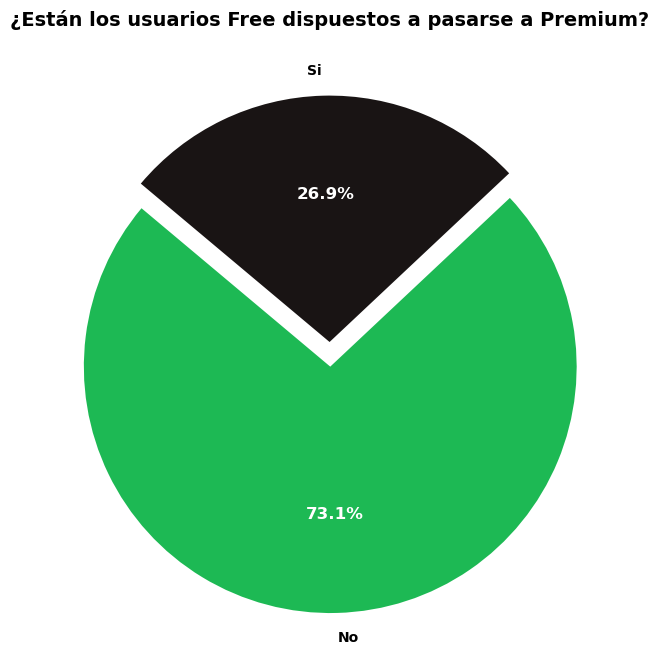

In [11]:
usuarios_free = Spotify_limpio[Spotify_limpio['SUSCRIPCION'] == 'Free']
conteo_disposicion = usuarios_free['QUIERE_PREMIUM'].value_counts()
plt.figure(figsize=(8, 8))
parches, textos_etiquetas, textos_porcentaje = plt.pie(
    conteo_disposicion, 
    labels=conteo_disposicion.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=['#1DB954', '#191414'], # Verde y Negro
    explode=(0.1, 0),
    textprops={'fontweight': 'bold'})
for t in textos_porcentaje:
    t.set_color('white')
    t.set_fontsize(12)

plt.title('¿Están los usuarios Free dispuestos a pasarse a Premium?', fontsize=14, fontweight='bold')
plt.show()

### ¿Qué perfil de usuario "Free" tiene más probabilidad de decir "Sí" a Premium según su valoración de las recomendaciones?

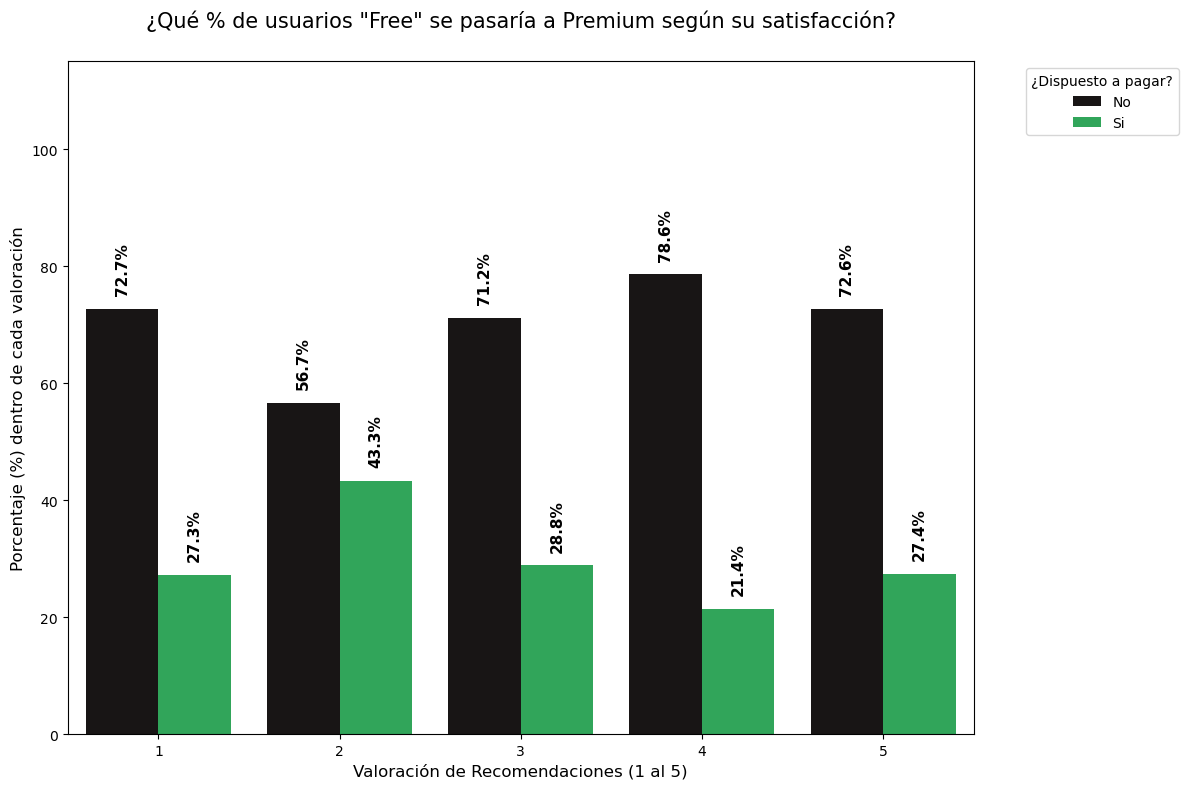

In [12]:
solo_free = Spotify_limpio[Spotify_limpio['SUSCRIPCION'] == 'Free'].copy()
df_plot = (solo_free.groupby('VALORACION_RECOMENDACIONES')['QUIERE_PREMIUM']
           .value_counts(normalize=True)
           .mul(100)
           .rename('PORCENTAJE')
           .reset_index())
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=df_plot, 
    x='VALORACION_RECOMENDACIONES', 
    y='PORCENTAJE', 
    hue='QUIERE_PREMIUM', 
    palette={'Si': '#1DB954', 'No': '#191414'})

for container in ax.containers:
    ax.bar_label(
        container, 
        fmt='%.1f%%', 
        padding=10, 
        rotation=90, 
        fontweight='bold', 
        fontsize=11
    )
plt.title('¿Qué % de usuarios "Free" se pasaría a Premium según su satisfacción?', fontsize=15, pad=25)
plt.xlabel("Valoración de Recomendaciones (1 al 5)", fontsize=12)
plt.ylabel('Porcentaje (%) dentro de cada valoración', fontsize=12)
plt.legend(title='¿Dispuesto a pagar?', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 115) 

plt.tight_layout()
plt.show()

### ¿Qué perfil de usuario "Premium" tiene más probabilidad de abandonar Premium según su valoración?

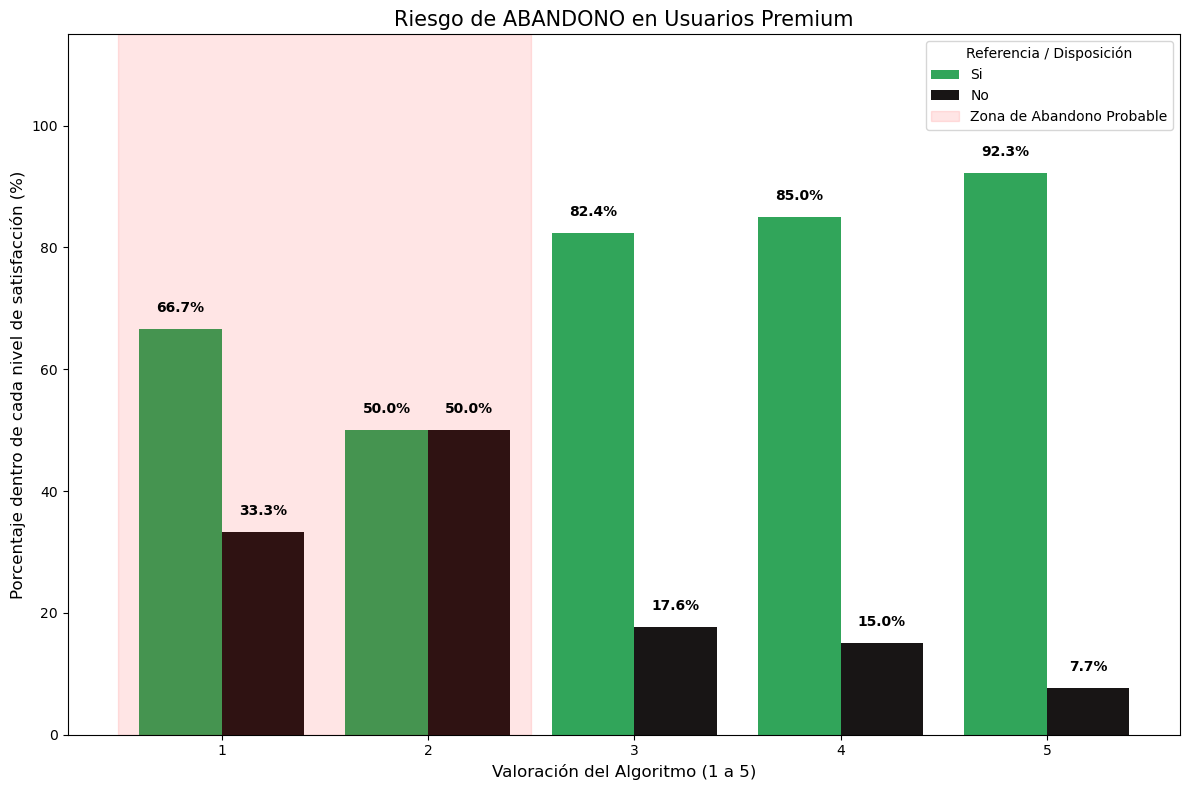

In [13]:
solo_premium = Spotify_limpio[Spotify_limpio['SUSCRIPCION'] == 'Premium'].copy()

df_abandono = (solo_premium.groupby('VALORACION_RECOMENDACIONES')['QUIERE_PREMIUM']
               .value_counts(normalize=True)
               .mul(100)
               .rename('PORCENTAJE')
               .reset_index())

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=df_abandono, 
    x='VALORACION_RECOMENDACIONES', 
    y='PORCENTAJE', 
    hue='QUIERE_PREMIUM', 
    palette={'Si': '#1DB954', 'No': '#191414'}
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=10, rotation=0, fontweight='bold')

plt.axvspan(-0.5, 1.5, color='red', alpha=0.1)

handles, labels = ax.get_legend_handles_labels()

zona_riesgo_patch = mpatches.Patch(color='red', alpha=0.1, label='Zona de Abandono Probable')

handles.append(zona_riesgo_patch)
plt.legend(handles=handles, title='Referencia / Disposición', loc='upper right')

plt.title('Riesgo de ABANDONO en Usuarios Premium', fontsize=15)
plt.xlabel('Valoración del Algoritmo (1 a 5)', fontsize=12)
plt.ylabel('Porcentaje dentro de cada nivel de satisfacción (%)', fontsize=12)

plt.ylim(0, 115) 
plt.tight_layout()
plt.show()

### ¿Qué perfil de usuario estaría dispuesto a pagar según su valoración?

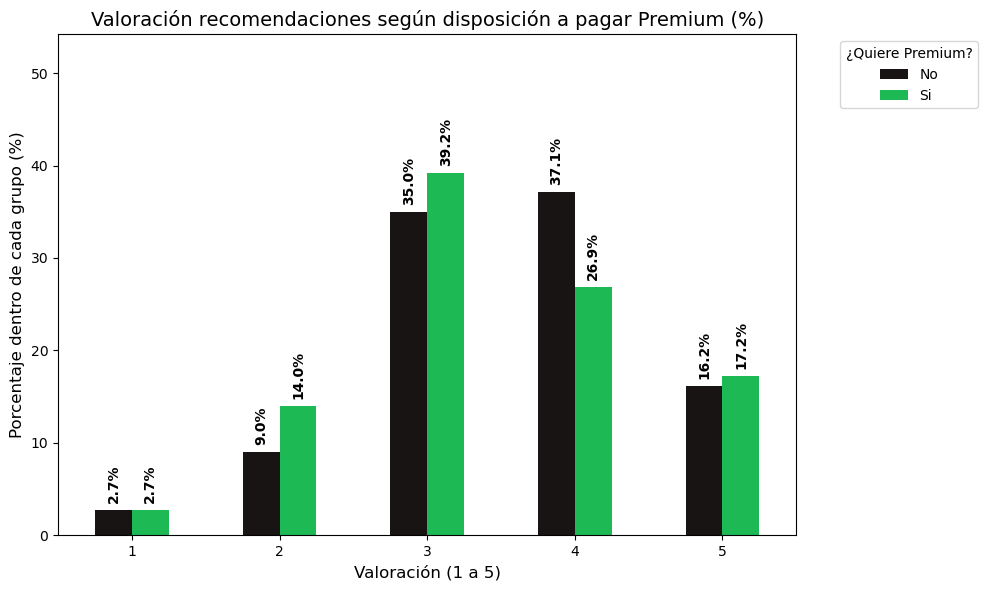

In [14]:
tabla_pct = pd.crosstab(
    Spotify_limpio["VALORACION_RECOMENDACIONES"],
    Spotify_limpio["QUIERE_PREMIUM"],
    normalize="columns"
).round(3) * 100

colores_spotify = ["#191414", "#1DB954"] 
ax = tabla_pct.plot(kind="bar", figsize=(10, 6), color=colores_spotify)
for container in ax.containers:
    ax.bar_label(
        container, 
        fmt='%.1f%%', 
        padding=5, 
        rotation=90, 
        fontsize=10, 
        fontweight='bold')

plt.title("Valoración recomendaciones según disposición a pagar Premium (%)", fontsize=14)
plt.xlabel("Valoración (1 a 5)", fontsize=12)
plt.ylabel("Porcentaje dentro de cada grupo (%)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="¿Quiere Premium?", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, tabla_pct.values.max() + 15)

plt.tight_layout()
plt.show()

### ¿Qué perfil de usuario "Premium" tiene más probabilidad de abandonar Premium según su satisfacción (Podcast)?

### ¿Qué perfil de usuario estaría dispuesto a pagar según su satisfacción (Podcasts)?

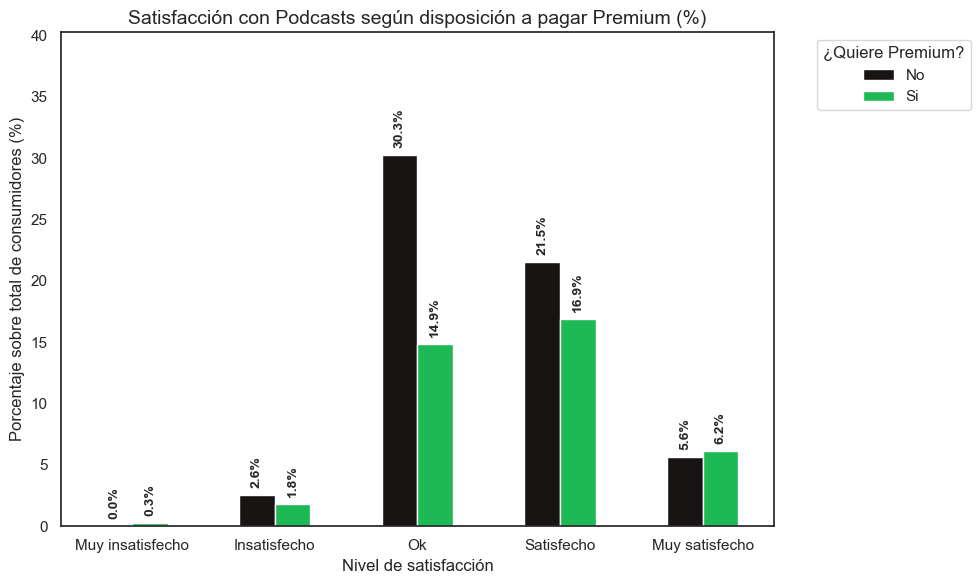

In [38]:
df_pod = Spotify_limpio[Spotify_limpio["CONSUME_PODCAST"] == True]

tabla_pct_pod = pd.crosstab(
    pd.Categorical(df_pod["SATISFACCION_POD"], categories=orden_satisfaccion, ordered=True),
    df_pod["QUIERE_PREMIUM"]
).divide(len(df_pod)) * 100

colores_spotify = ["#191414", "#1DB954"] 
ax = tabla_pct_pod.plot(kind="bar", figsize=(10, 6), color=colores_spotify)
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=5,
        rotation=90,
        fontsize=10,
        fontweight='bold'
    )

plt.title("Satisfacción con Podcasts según disposición a pagar Premium (%)", fontsize=14)
plt.xlabel("Nivel de satisfacción", fontsize=12)
plt.ylabel("Porcentaje sobre total de consumidores (%)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="¿Quiere Premium?", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, tabla_pct_pod.values.max() + 10)

plt.tight_layout()
plt.show()

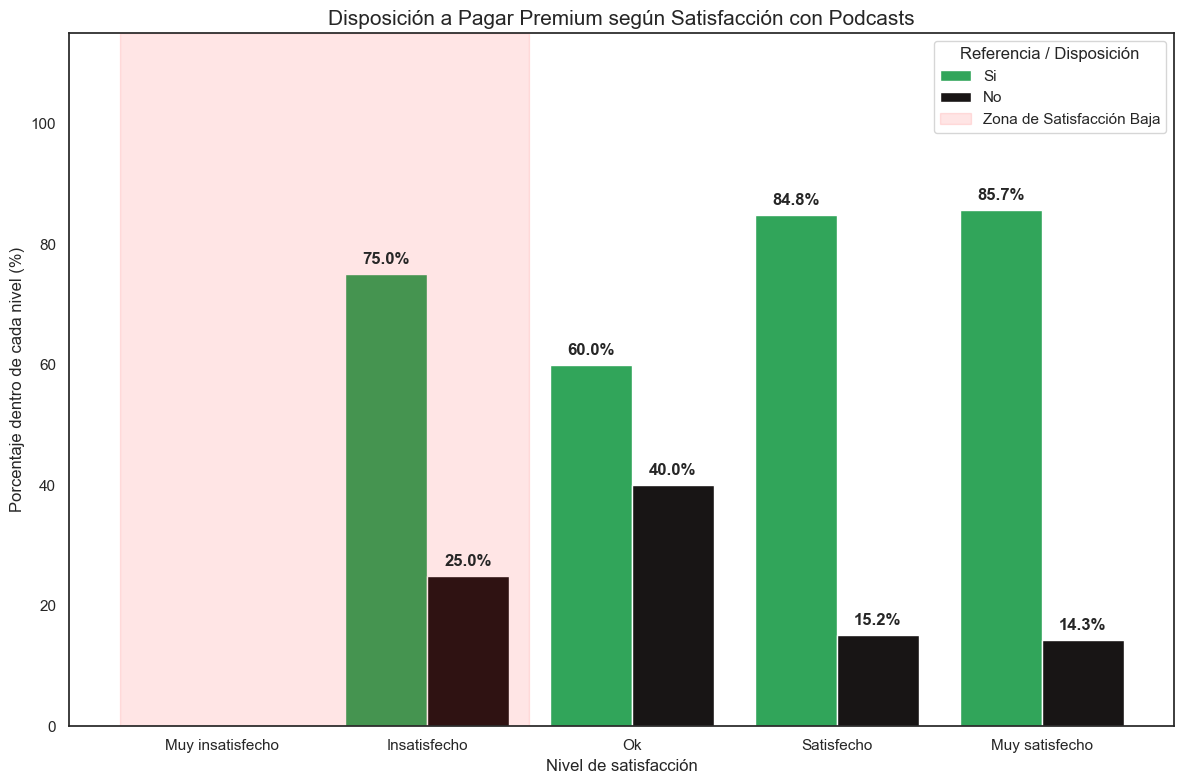

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import pandas as pd

# Filtrar solo usuarios Premium que además consumen podcasts
solo_premium = Spotify_limpio[
    (Spotify_limpio['SUSCRIPCION'] == 'Premium') &
    (Spotify_limpio['CONSUME_PODCAST'] == True)
].copy()

# Crear dataframe con porcentaje por nivel de satisfacción y disposición a pagar
df_abandono = (solo_premium.groupby('SATISFACCION_POD')['QUIERE_PREMIUM']
               .value_counts(normalize=True)
               .mul(100)
               .rename('PORCENTAJE')
               .reset_index())

# Ordenar categorías de satisfacción
orden_satisfaccion = ["Muy insatisfecho","Insatisfecho","Ok","Satisfecho","Muy satisfecho"]
df_abandono['SATISFACCION_POD'] = pd.Categorical(
    df_abandono['SATISFACCION_POD'], 
    categories=orden_satisfaccion, 
    ordered=True
)

plt.figure(figsize=(12, 8))

# Gráfico de barras
ax = sns.barplot(
    data=df_abandono, 
    x='SATISFACCION_POD', 
    y='PORCENTAJE', 
    hue='QUIERE_PREMIUM', 
    palette={'Si': '#1DB954', 'No': '#191414'}
)

# Añadir porcentajes encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5, rotation=0, fontweight='bold')

# Zona de riesgo: niveles bajos de satisfacción
plt.axvspan(-0.5, 1.5, color='red', alpha=0.1)

# Leyenda incluyendo zona de riesgo
handles, labels = ax.get_legend_handles_labels()
zona_riesgo_patch = mpatches.Patch(color='red', alpha=0.1, label='Zona de Satisfacción Baja')
handles.append(zona_riesgo_patch)
plt.legend(handles=handles, title='Referencia / Disposición', loc='upper right')

plt.title('Disposición a Pagar Premium según Satisfacción con Podcasts', fontsize=15)
plt.xlabel('Nivel de satisfacción', fontsize=12)
plt.ylabel('Porcentaje dentro de cada nivel (%)', fontsize=12)
plt.ylim(0, 115) 
plt.tight_layout()
plt.show()

## PSICOLOGÍA DEL USUARIO: ÁNIMO Y ALGORITMOP

### Influencia del Estado Emocional en la Elección Musical

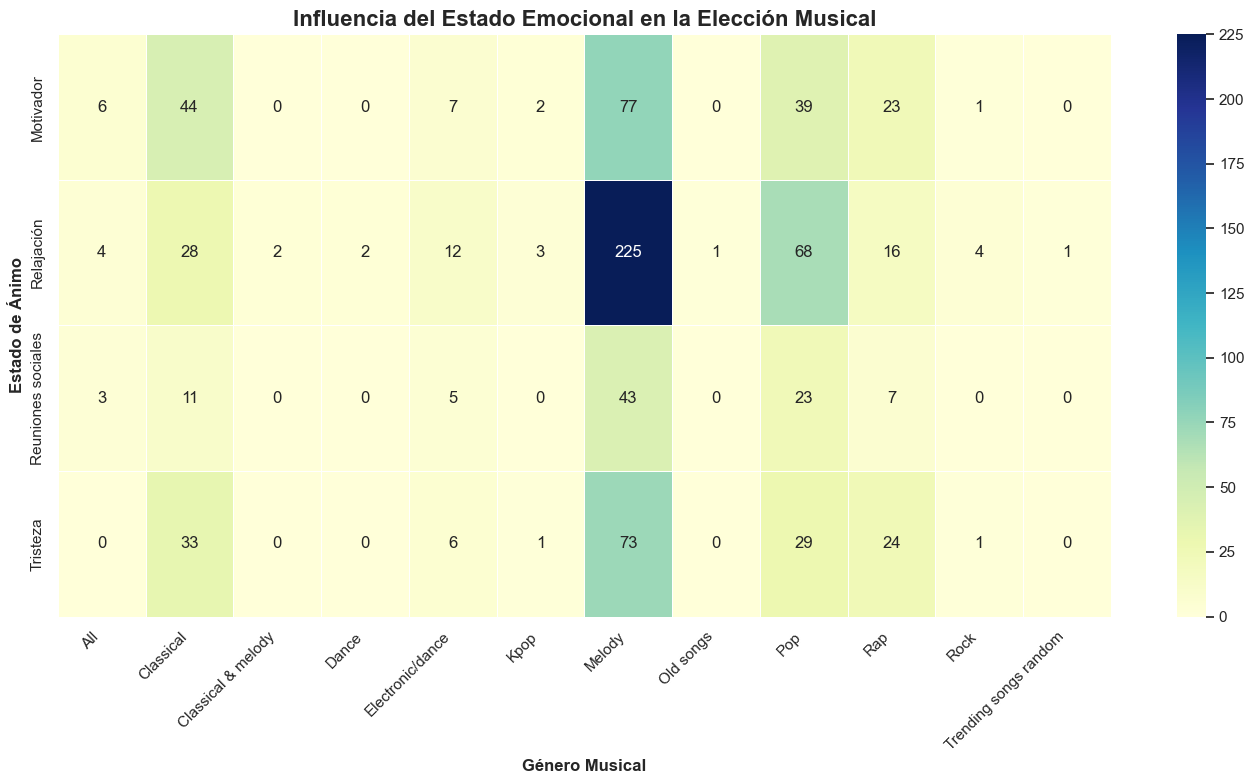

In [27]:
df_mood = Spotify_limpio.copy()

df_mood['ESTADO_ANIMO'] = df_mood['ESTADO_ANIMO'].str.split(r',\s*')
df_mood = df_mood.explode('ESTADO_ANIMO')
df_mood['ESTADO_ANIMO'] = df_mood['ESTADO_ANIMO'].str.strip().str.capitalize()

df_mood['GENERO_FAV_MUSICA'] = df_mood['GENERO_FAV_MUSICA'].str.split(r',\s*')
df_mood = df_mood.explode('GENERO_FAV_MUSICA')
df_mood['GENERO_FAV_MUSICA'] = df_mood['GENERO_FAV_MUSICA'].str.strip().str.capitalize()

df_mood = df_mood[(df_mood['ESTADO_ANIMO'] != '') & (df_mood['GENERO_FAV_MUSICA'] != '')]

tabla_relacion = pd.crosstab(df_mood['ESTADO_ANIMO'], df_mood['GENERO_FAV_MUSICA'])

plt.figure(figsize=(14, 8))
sns.heatmap(
    tabla_relacion, 
    annot=True, 
    fmt="d", 
    cmap="YlGnBu", 
    linewidths=.5
)

plt.title("Influencia del Estado Emocional en la Elección Musical", fontsize=16, fontweight='bold')
plt.xlabel("Género Musical", fontsize=12,fontweight='bold')
plt.ylabel("Estado de Ánimo", fontsize=12,fontweight='bold')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()